In [1]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df=pd.read_csv("Fish.csv")
y=df["Species"]
x=df.drop("Species",axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
knn.predict([[150,10,12,10,7,5]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Parkki'], dtype=object)

[[7 0 3 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 8 0 1 0 0]
 [1 0 2 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 5 0]
 [0 0 3 0 0 0 0]]


<Axes: >

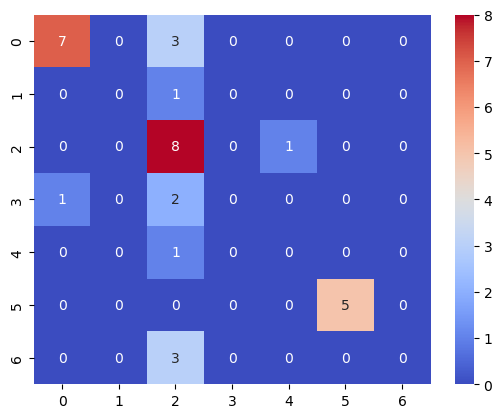

In [16]:
print(confusion_matrix(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap="coolwarm")

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       Bream       0.88      0.70      0.78        10
      Parkki       0.00      0.00      0.00         1
       Perch       0.44      0.89      0.59         9
        Pike       0.00      0.00      0.00         3
       Roach       0.00      0.00      0.00         1
       Smelt       1.00      1.00      1.00         5
   Whitefish       0.00      0.00      0.00         3

    accuracy                           0.62        32
   macro avg       0.33      0.37      0.34        32
weighted avg       0.55      0.62      0.57        32



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [37]:
df=pd.read_csv("titanic.csv")
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [38]:
df.isna().sum()

pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64

In [39]:
df=df.drop("cabin",axis=1)

In [41]:
df=df.fillna(df.mean(numeric_only=True))
df["embarked"]=df.embarked.fillna(df.embarked.mode([0]))
df.isna().sum()

pclass      0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
embarked    2
survived    0
dtype: int64

In [43]:
df=df.drop(["name","ticket"],axis=1)

In [45]:
df=pd.get_dummies(df,drop_first=True)

In [46]:
df.head()

,pclass,age,sibsp,parch,fare,survived,sex_male,embarked_Q,embarked_S
0,1,29.0000,0,0,211.3375,1,False,False,True
1,1,0.9167,1,2,151.5500,1,True,False,True
2,1,2.0000,1,2,151.5500,0,False,False,True
3,1,30.0000,1,2,151.5500,0,True,False,True
4,1,25.0000,1,2,151.5500,0,False,False,True


In [47]:
y=df["survived"]
x=df.drop("survived",axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
knn=KNeighborsClassifier(n_neighbors=37)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)

In [49]:
confusion_matrix(y_pred,y_test)

array([[129,  71],
       [ 15,  47]])

In [50]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.90      0.65      0.75       200
           1       0.40      0.76      0.52        62

    accuracy                           0.67       262
   macro avg       0.65      0.70      0.64       262
weighted avg       0.78      0.67      0.70       262



# DT

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [4]:
df=pd.read_csv("PlayTennis.csv")
df

,outlook,temp,humidity,windy,play
0,sunny,hot,high,False,no
1,sunny,hot,high,True,no
2,overcast,hot,high,False,yes
3,rainy,mild,high,False,yes
4,rainy,cool,normal,False,yes
5,rainy,cool,normal,True,no
6,overcast,cool,normal,True,yes
7,sunny,mild,high,False,no
8,sunny,cool,normal,False,yes
9,rainy,mild,normal,False,yes


In [5]:
x=df.drop('play',axis=1)
x=pd.get_dummies(x)
y=df['play']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

1.0
              precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



[Text(0.625, 0.875, 'outlook_overcast <= 0.5\nentropy = 0.946\nsamples = 11\nvalue = [4, 7]'),
 Text(0.5, 0.625, 'humidity_high <= 0.5\nentropy = 1.0\nsamples = 8\nvalue = [4, 4]'),
 Text(0.5625, 0.75, 'True  '),
 Text(0.25, 0.375, 'windy <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [1, 3]'),
 Text(0.125, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.375, 'outlook_sunny <= 0.5\nentropy = 0.811\nsamples = 4\nvalue = [3, 1]'),
 Text(0.625, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.6875, 0.75, '  False')]

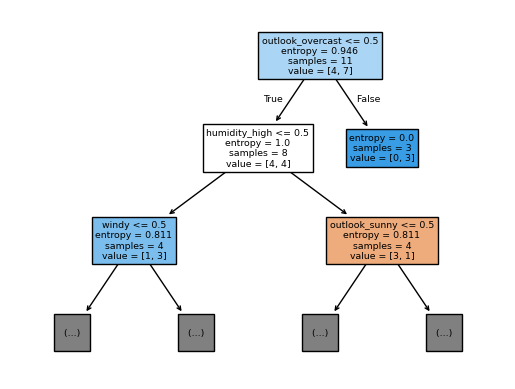

In [6]:
from sklearn.tree import plot_tree
plot_tree(dt,feature_names=x.columns,filled=True,max_depth=2)

In [7]:
df=pd.read_csv('diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


0.7207792207792207
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        99
           1       0.60      0.64      0.62        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



[Text(0.47609544836956524, 0.9705882352941176, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.17909307065217392, 0.9117647058823529, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.32759425951086957, 0.9411764705882353, 'True  '),
 Text(0.06521739130434782, 0.8529411764705882, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.021739130434782608, 0.7941176470588235, 'DiabetesPedigreeFunction <= 0.672\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.010869565217391304, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.03260869565217391, 0.7352941176470589, 'DiabetesPedigreeFunction <= 0.686\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.021739130434782608, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.043478260869565216, 0.6764705882352942, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.10869565217391304, 0.7941

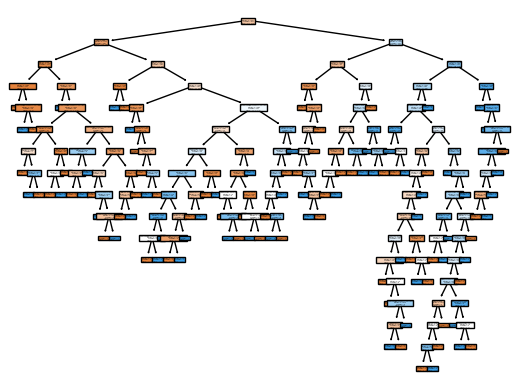

In [8]:
x=df.drop('Outcome',axis=1)
x=pd.get_dummies(x)
y=df['Outcome']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
dt=DecisionTreeClassifier(criterion='entropy',random_state=42)
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
plot_tree(dt,feature_names=x.columns,filled=True)

# Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [10]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [45]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rf=RandomForestClassifier(criterion="entropy",random_state=42,n_estimators=54)

0.7727272727272727
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       100
           1       0.67      0.69      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



[Text(0.47609544836956524, 0.9705882352941176, 'Glucose <= 127.5\nentropy = 0.931\nsamples = 614\nvalue = [401, 213]'),
 Text(0.17909307065217392, 0.9117647058823529, 'Age <= 28.5\nentropy = 0.712\nsamples = 390\nvalue = [314, 76]'),
 Text(0.32759425951086957, 0.9411764705882353, 'True  '),
 Text(0.06521739130434782, 0.8529411764705882, 'BMI <= 30.95\nentropy = 0.391\nsamples = 221\nvalue = [204, 17]'),
 Text(0.021739130434782608, 0.7941176470588235, 'DiabetesPedigreeFunction <= 0.672\nentropy = 0.068\nsamples = 124\nvalue = [123, 1]'),
 Text(0.010869565217391304, 0.7352941176470589, 'entropy = 0.0\nsamples = 108\nvalue = [108, 0]'),
 Text(0.03260869565217391, 0.7352941176470589, 'DiabetesPedigreeFunction <= 0.686\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.021739130434782608, 0.6764705882352942, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.043478260869565216, 0.6764705882352942, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.10869565217391304, 0.7941

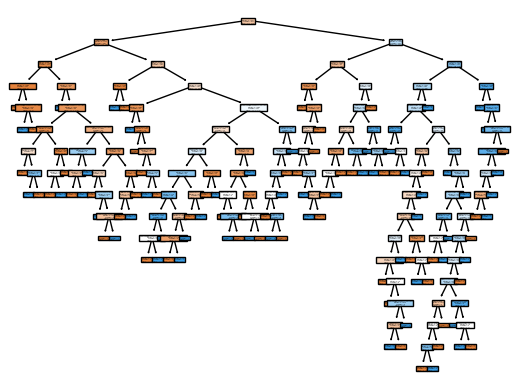

In [46]:
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))
plot_tree(dt,feature_names=x.columns,filled=True)

In [52]:
df=pd.read_csv("titanic.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [53]:
df=df.drop(["name","ticket","cabin"],axis=1)

In [55]:
df.isna().sum()

pclass        0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
survived      0
dtype: int64

In [56]:
df.embarked=df.embarked.fillna(df.embarked.mode()[0])
df=df.fillna(df.mean(numeric_only=True))

In [58]:
y=df['survived']
x=df.drop("survived",axis=1)
x=pd.get_dummies(x)

In [59]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

In [63]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ac_knn=0
for i in range(27,45):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_knn:
        ac_knn=ac
        neighbore=i
print(ac,">",neighbore)

0.6526717557251909 > 39


In [64]:
ac_dt=0
for i in range(1,50):
    DT=DecisionTreeClassifier(criterion="entropy",random_state=42,max_depth=i)
    DT.fit(x_train,y_train)
    y_pred=DT.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac,'>',depth)

0.7557251908396947 > 3


In [69]:
ac_rf=0
for i in range(30,100):
    RF=RandomForestClassifier(criterion="entropy",random_state=42,n_estimators=i)
    RF.fit(x_train,y_train)
    y_pred=RF.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_rf:
        ac_rf=ac
        estimetors=i
print(ac,'>',estimetors)

0.7786259541984732 > 45


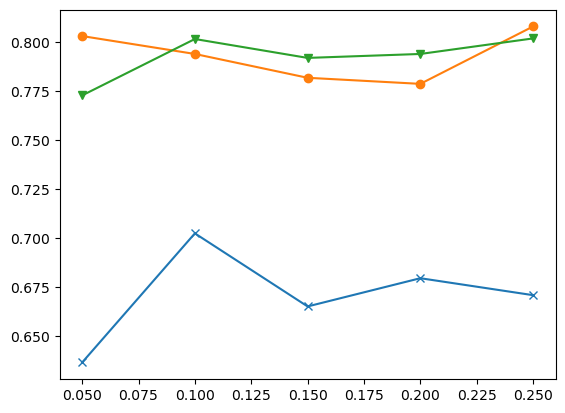

In [72]:
ac_knn=[]
ac_dt=[]
ac_rf=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=i,random_state=42)
    knn=KNeighborsClassifier(n_neighbors=39)
    dt=DecisionTreeClassifier(max_depth=3,criterion="entropy",random_state=42)
    rf=RandomForestClassifier(n_estimators=45,criterion="entropy",random_state=42)

    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac_knn.append(accuracy_score(y_pred,y_test))

    dt.fit(x_train,y_train)
    y_pred=dt.predict(x_test)
    ac_dt.append(accuracy_score(y_pred,y_test))

    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac_rf.append(accuracy_score(y_pred,y_test))
    
plt.plot(test,ac_knn,marker='x')
plt.plot(test,ac_dt,marker='o')
plt.plot(test,ac_rf,marker='v')

In [8]:
from sklearn.svm import SVC

In [9]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [12]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
svm=SVC(C=1,random_state=42,kernel='rbf')
svm.fit(x_train,y_train)
y_pred=svm.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        99
           1       0.72      0.56      0.63        55

    accuracy                           0.77       154
   macro avg       0.75      0.72      0.73       154
weighted avg       0.76      0.77      0.76       154

